In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

In [2]:
SUMMARY_DIR = Path("./results")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))

df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)


SUMMARY_DIR = Path("./results_open_positions_V0")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))

df_open_pos_V0 = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)


df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()

df_open_pos_V0["day"] = pd.to_datetime(df_open_pos_V0["day"] , utc=True).dt.normalize()


ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)

df = df.merge(ri_base, on="day", how="left")

df["uplift_abs"] = df["profit"] - df["RI_base"]
df["uplift_pct"] = df["uplift_abs"] / df["RI_base"]



df_open_pos_V0 = df_open_pos_V0.merge(ri_base, on="day", how="left")

df_open_pos_V0["uplift_abs"] = df_open_pos_V0["profit"] - df_open_pos_V0["RI_base"]
df_open_pos_V0["uplift_pct"] = df_open_pos_V0["uplift_abs"] / df_open_pos_V0["RI_base"]

In [4]:
df

,day,combo_id,kind,buy_hour,sell_hour,profit,da_exec_time,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_abs,uplift_pct
0,2018-12-31 00:00:00+00:00,0,no_da,NaN,NaN,68.233139,2018-12-31 13:00:00,0.00,NaN,NaN,0.00,68.233139,0.000000,0.000000
1,2018-12-31 00:00:00+00:00,1,buy_only,1.0,NaN,61.759133,2018-12-31 13:00:00,-28.32,28.32,NaN,-0.46,68.233139,-6.474006,-0.094881
2,2018-12-31 00:00:00+00:00,2,buy_only,2.0,NaN,60.593526,2018-12-31 13:00:00,-10.07,10.07,NaN,-0.17,68.233139,-7.639613,-0.111963
3,2018-12-31 00:00:00+00:00,3,buy_only,3.0,NaN,80.214991,2018-12-31 13:00:00,4.08,-4.08,NaN,0.05,68.233139,11.981852,0.175602
4,2018-12-31 00:00:00+00:00,4,buy_only,4.0,NaN,69.708946,2018-12-31 13:00:00,9.91,-9.91,NaN,0.14,68.233139,1.475806,0.021629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547795,2023-12-30 00:00:00+00:00,295,buy_sell,21.0,23.0,93.694603,NaN,NaN,NaN,NaN,NaN,91.401496,2.293107,0.025088
547796,2023-12-30 00:00:00+00:00,296,buy_sell,21.0,24.0,83.358138,NaN,NaN,NaN,NaN,NaN,91.401496,-8.043358,-0.088000
547797,2023-12-30 00:00:00+00:00,297,buy_sell,22.0,23.0,100.283948,NaN,NaN,NaN,NaN,NaN,91.401496,8.882452,0.097181
547798,2023-12-30 00:00:00+00:00,298,buy_sell,22.0,24.0,92.532591,NaN,NaN,NaN,NaN,NaN,91.401496,1.131095,0.012375


In [5]:
df = df.loc[df["day"] < pd.Timestamp("2025-12-31", tz="UTC")].copy()
#df_open_pos = df_open_pos.loc[df_open_pos["day"] < pd.Timestamp("2020-12-31", tz="UTC")].copy()

df.loc[(df["kind"] != "no_da") & (df["sell_hour"].isna()), "sell_hour"] = 0

In [6]:
df["buy_interval"] = np.select(
    [
        df["buy_hour"] == 0,
        df["buy_hour"].between(1, 5),
        df["buy_hour"].between(6, 11),
        df["buy_hour"].between(12, 17),
        df["buy_hour"].between(18, 23)
    ],
    [0, 1, 2, 3, 4],
    default=np.nan
)

df["sell_interval"] = np.select(
    [
        df["sell_hour"] == 0,
        df["sell_hour"].between(2, 6),
        df["sell_hour"].between(7, 12),
        df["sell_hour"].between(13, 18),
        df["sell_hour"].between(19, 24)
    ],
    [0, 1, 2, 3, 4],
    default=np.nan
)

#### Load drl observation space features

In [7]:
drl_obs_data = pd.read_csv("../data/simplified_data_jan_with_exaa_and_id_full/df_spot_train_2019-01-01_2024-12-31_with_features_utc.csv")
drl_obs_data["time"] = pd.to_datetime(drl_obs_data["time"], utc=True)
drl_obs_data.set_index("time", inplace=True)
drl_obs_data = drl_obs_data.resample('D').mean()
drl_obs_data.reset_index(inplace=True)
drl_obs_data["date"] = drl_obs_data["time"].dt.date
drl_obs_data

df["day"] = pd.to_datetime(df["day"].astype(str).str.slice(0, 10), errors="coerce")
df["day_utc"] = df["day"].dt.tz_localize("UTC")
df["date"] = df["day_utc"].dt.date
df

df_merged = df.merge(
    drl_obs_data,
    on="date",
    how="left"
)

In [8]:
df1= df_merged.copy()

In [9]:

columns_to_keep = [ 'date',"combo_id", 'buy_hour', 'sell_hour',"buy_interval", "sell_interval",'profit',
      'uplift_abs', 'uplift_pct',
      'da_profit', 'da_buy_price', 'da_sell_price',
       'load_forecast_d_minus_1_1000_total_de_lu_mw',
       'pv_forecast_d_minus_1_1000_de_lu_mw',
       'wind_offshore_forecast_d_minus_1_1000_de_lu_mw',
       'wind_onshore_forecast_d_minus_1_1000_de_lu_mw', 'date_month',
       'day_of_week', 'wind_forecast_daily_mean', 'wind_forecast_daily_std',
       'spread_id_full_da_h_mean', 'spread_id_full_da_h_std',
       'spread_id_full_da_h_min', 'spread_id_full_da_h_max',
       'spread_id_full_da_qh_mean', 'spread_id_full_da_qh_std',
       'spread_id_full_da_qh_min', 'spread_id_full_da_qh_max',
       'exaa_pf_daily_mean', 'exaa_pf_daily_std', 'exaa_pf_daily_min',
       'exaa_pf_daily_max', 'exaa_pf_daily_spread', 'exaa_pf_daily_diff_sum',
       'exaa_pf_daily_diff_max']

df1= df_merged[columns_to_keep]



df1["buy_hour"] = df1["buy_hour"].fillna(0)
df1["sell_hour"] = df1["sell_hour"].fillna(0)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_47135/1992780577.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["buy_hour"] = df1["buy_hour"].fillna(0)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_47135/1992780577.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["sell_hour"] = df1["sell_hour"].fillna(0)


In [10]:
df1.drop(columns=['buy_hour', "sell_hour"], axis=1, inplace=True)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_47135/2266798516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(columns=['buy_hour', "sell_hour"], axis=1, inplace=True)


In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# ========== Data / Split ==========
y_col = "profit"
group_col = "date"

groups = df1[group_col]

exclude = {
    "profit", "uplift_abs", "uplift_pct",
    "uplift_pos", "uplift_pos_5pct",
    "day", "time", "datetime", group_col
}
feature_cols = [c for c in df1.columns if c not in exclude]

X = df1[feature_cols]
y = df1[y_col]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

# ========== Models ==========
models = {}

# LightGBM
try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        max_depth=10,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
except Exception as e:
    print("LightGBM nicht verfügbar:", repr(e))

# CatBoost
try:
    from catboost import CatBoostRegressor
    models["CatBoost"] = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=10,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )
except Exception as e:
    print("CatBoost nicht verfügbar:", repr(e))

# XGBoost
try:
    from xgboost import XGBRegressor
    models["XGBoost"] = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
except Exception as e:
    print("XGBoost nicht verfügbar:", repr(e))

# RandomForest
from sklearn.ensemble import RandomForestRegressor
models["RandomForest"] = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

# HistGradientBoosting
from sklearn.ensemble import HistGradientBoostingRegressor
models["HistGB"] = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=None,
    max_iter=800,
    random_state=42
)

# ========== Train / Evaluate ==========
results = []
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, pred)  # echtes RMSE
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)

    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})
    preds[name] = pred

results_df = pd.DataFrame(results).sort_values("rmse")
print(results_df.to_string(index=False))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6432
[LightGBM] [Info] Number of data points in the train set: 438000, number of used features: 29
[LightGBM] [Info] Start training from score 174.442622
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


KeyboardInterrupt: 

In [37]:
model = "CatBoost"      # "LightGBM", "XGBoost", "RandomForest", "HistGB"
pred = preds[model]
print("Gewähltes Modell:", model)

Gewähltes Modell: CatBoost


In [38]:
# --- direkt nach pred = model.predict(X_test) ---
plot_df = df1.iloc[test_idx].copy()
plot_df["profit_actual"] = y_test.values
plot_df["profit_forecast"] = pred

plot_df["date"] = pd.to_datetime(plot_df["date"]).dt.date
plot_df["combo_id"] = plot_df["combo_id"].astype(int)

baseline_map = (
    plot_df.loc[plot_df["combo_id"] == 0]
           .groupby("date")["profit_actual"]
           .mean()
)

plot_df["baseline"] = plot_df["date"].map(baseline_map)

In [39]:
import matplotlib.pyplot as plt

def plot_random_day(plot_df, seed=None, day=None):
    rng = np.random.default_rng(seed)

    days = plot_df["date"].dropna().unique()
    if len(days) == 0:
        raise ValueError("Keine 'day'-Werte gefunden.")

    if day is None:
        day = rng.choice(days)

    tmp = plot_df[plot_df["date"] == day].copy().sort_values("combo_id")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(tmp["combo_id"], tmp["profit_actual"], label="actual", marker="o", linewidth=1)
    ax.plot(tmp["combo_id"], tmp["profit_forecast"], label="forecast", marker="o", linewidth=1)

    # Baseline
    base = tmp["baseline"].iloc[0] if len(tmp) else np.nan
    if pd.notna(base):
        ax.axhline(base, label="baseline", linewidth=2)
    else:
        ax.text(0.01, 0.95,
                transform=ax.transAxes, va="top")

    ax.set_title(f"Actual vs Forecast + Baseline - day={day} (n={len(tmp)})")
    ax.set_xlabel("combo_id (0..299)")
    ax.set_ylabel("profit")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return day




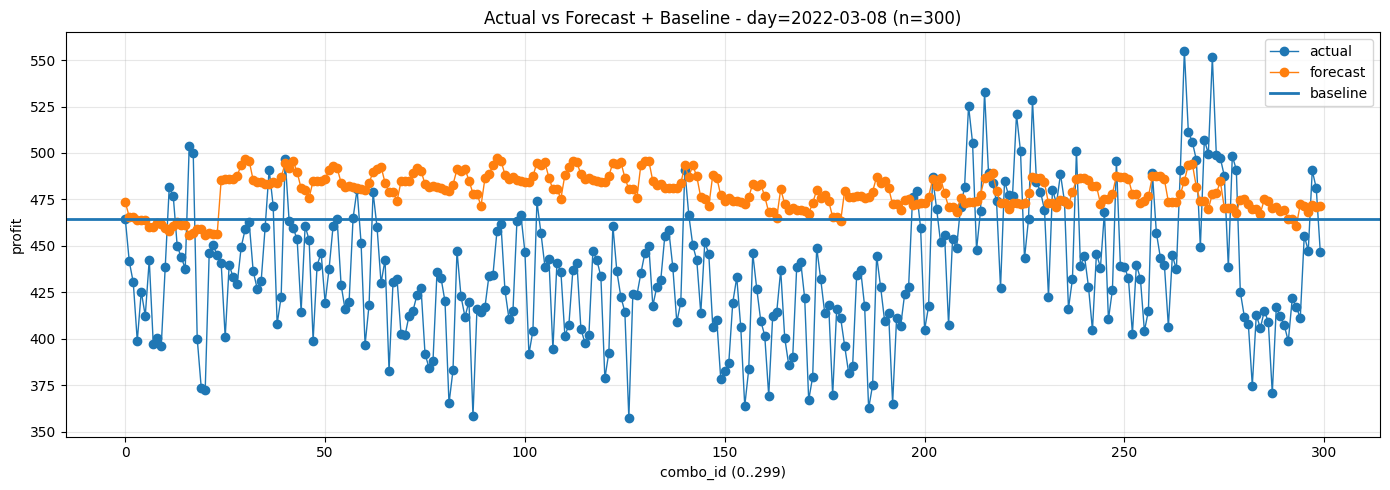

datetime.date(2022, 3, 8)

In [70]:
plot_random_day(plot_df)


#### Evaluation

In [90]:
import numpy as np
import pandas as pd

group_col = "date"
uplift_col = "uplift_pct"
k = 30

df_test = df1.iloc[test_idx].copy()

if uplift_col not in df_test.columns:
    raise KeyError(f"Spalte '{uplift_col}' fehlt in df1/test.")

# Tages-"Schwierigkeit" (modellunabhängig)
day_stats = (
    df_test.groupby(group_col)
    .agg(
        n_combos=(uplift_col, "size"),
        share_pos_all=(uplift_col, lambda s: (s > 0).mean()),
        mean_uplift_all=(uplift_col, "mean"),
        median_uplift_all=(uplift_col, "median"),
        sum_pos_all=(uplift_col, lambda s: s[s > 0].sum()),
        sum_neg_all=(uplift_col, lambda s: s[s < 0].sum()),
    )
    .reset_index()
)

def topk_indices_per_day(df, group_col, score_col, k=10):
    # Gibt EINEN flachen Index zurück (kein "Index von Indexen")
    idx = (
        df.groupby(group_col, group_keys=False)
          .apply(lambda g: g[score_col].nlargest(min(k, len(g))).index)
    )
    # idx ist eine Series, deren Werte jeweils Index-Objekte sind -> flatten:
    flat = np.concatenate([x.to_numpy() for x in idx.to_list()]) if len(idx) else np.array([], dtype=int)
    return pd.Index(flat)

def compute_overlap_topk(df, group_col, pred_col, uplift_col, k=10):
    """
    Returns a Series indexed by group_col with:
    overlap = |Top-k(pred) ∩ Top-k(true)|
    """
    def overlap_one_day(g):
        pred_topk = set(g[pred_col].nlargest(k).index)
        true_topk = set(g[uplift_col].nlargest(k).index)
        return len(pred_topk & true_topk)

    return (
        df.groupby(group_col)
          .apply(overlap_one_day)
          .rename("overlap_topk")
          .reset_index()
    )


model_summaries = []
per_day_details = {}

for model_name, pred in preds.items():
    pred_col = f"pred_{model_name}"

    d = df_test.copy()
    d[pred_col] = pred

    # predicted Top-k Zeilen (über alle Tage zusammen)
    topk_idx = topk_indices_per_day(d, group_col, pred_col, k=k)
    topk = d.loc[topk_idx].copy()

    # Top-k Performance pro Tag
    topk_day = (
        topk.groupby(group_col)
            .agg(
                share_pos_topk=(uplift_col, lambda s: (s > 0).mean()),
                mean_uplift_topk=(uplift_col, "mean"),
                median_uplift_topk=(uplift_col, "median"),
                sum_pos_topk=(uplift_col, lambda s: s[s > 0].sum()),
                sum_neg_topk=(uplift_col, lambda s: s[s < 0].sum()),
            )
            .reset_index()
    )

    topk_day["pos_neg_ratio_topk"] = topk_day["sum_pos_topk"] / (np.abs(topk_day["sum_neg_topk"]) + 1e-9)

    # Overlap predicted Top-k vs true Top-k pro Tag
    overlap = compute_overlap_topk(
        d,
        group_col=group_col,
        pred_col=pred_col,
        uplift_col=uplift_col,
        k=k,
    )

    merged = (
    day_stats
      .merge(topk_day, on=group_col, how="left")
      .merge(overlap, on=group_col, how="left")
    )
    merged["model"] = model_name
    per_day_details[model_name] = merged

    model_summaries.append({
    "model": model_name,
    "k": k,
    "days": merged[group_col].nunique(),

    # Qualität der Modell-Top-10
    "avg_share_pos_topk": merged["share_pos_topk"].mean(),
    "avg_mean_uplift_pred_top10": merged["mean_uplift_topk"].mean(),
    "avg_overlap_share_topk": (merged["overlap_topk"] / k).mean(),

    # Upper bound: echte Top-10
    "avg_mean_uplift_true_top10": (
        d.groupby(group_col)[uplift_col]
         .apply(lambda s: s.nlargest(min(k, len(s))).mean())
         .mean()
    ),

    # Kontext
    "avg_share_pos_all": merged["share_pos_all"].mean(),
    "avg_mean_uplift_all": merged["mean_uplift_all"].mean(),
})

summary_df = pd.DataFrame(model_summaries).sort_values(
    ["avg_share_pos_topk"], ascending=False
)

print(f"\n=== Ranking-Evalu(Top {k} pro Tag) ===")
print(summary_df.to_string(index=False))



/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_14384/2662951160.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[score_col].nlargest(min(k, len(g))).index)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_14384/2662951160.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(overlap_one_day)
/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_14384/2662951160.


=== Ranking-Evalu(Top 30 pro Tag) ===
       model  k  days  avg_share_pos_topk  avg_mean_uplift_pred_top10  avg_overlap_share_topk  avg_mean_uplift_true_top10  avg_share_pos_all  avg_mean_uplift_all
    CatBoost 30   293            0.524460                    0.018039                0.165529                    0.184244           0.421991            -0.031689
     XGBoost 30   293            0.513879                    0.018527                0.150853                    0.184244           0.421991            -0.031689
    LightGBM 30   293            0.509443                    0.015332                0.153697                    0.184244           0.421991            -0.031689
      HistGB 30   293            0.502275                    0.014124                0.154835                    0.184244           0.421991            -0.031689
RandomForest 30   293            0.494881                    0.010794                0.147440                    0.184244           0.421991           

In [92]:
summary_df.round(2)

,model,k,days,avg_share_pos_topk,avg_mean_uplift_pred_top10,avg_overlap_share_topk,avg_mean_uplift_true_top10,avg_share_pos_all,avg_mean_uplift_all
1,CatBoost,30,293,0.52,0.02,0.17,0.18,0.42,-0.03
2,XGBoost,30,293,0.51,0.02,0.15,0.18,0.42,-0.03
0,LightGBM,30,293,0.51,0.02,0.15,0.18,0.42,-0.03
4,HistGB,30,293,0.50,0.01,0.15,0.18,0.42,-0.03
3,RandomForest,30,293,0.49,0.01,0.15,0.18,0.42,-0.03


In [82]:
model_name = "CatBoost"
pred_col = f"pred_{model_name}"

d = df_test.copy()
d[pred_col] = preds[model_name]

# Pro Tag Zusatzinfos
def inspect_day(df, day, k=10):
    g = df[df[group_col] == day].copy()

    g = g.sort_values(pred_col, ascending=False)

    out = g.assign(
        rank_pred=np.arange(1, len(g) + 1),
        rank_true=g[uplift_col].rank(ascending=False, method="first")
    )

    return {
        "all": out,
        "pred_top10": out.head(k),
        "true_top10": out.sort_values(uplift_col, ascending=False).head(k),
    }

# Beispiel: zufällige 5 Tage anschauen
days = d[group_col].unique()
np.random.seed(42)
sample_days = np.random.choice(days, size=50, replace=False)

for day in sample_days:
    res = inspect_day(d, day, k=10)

    print(f"\n=== DAY {day} ===")
    print("Predicted Top-10:")
    print(res["pred_top10"][[pred_col, uplift_col, "rank_true"]].to_string(index=False))

    print("\nTrue Top-10:")
    print(res["true_top10"][[pred_col, uplift_col, "rank_pred"]].to_string(index=False))

    print(
        "\nSummary:",
        f"share_pos_all = {(res['all'][uplift_col] > 0).mean():.2f}",
        f"| share_pos_pred_top10 = {(res['pred_top10'][uplift_col] > 0).mean():.2f}",
        f"| mean_uplift_pred_top10 = {res['pred_top10'][uplift_col].mean():.2f}",
    )




=== DAY 2020-02-29 ===
Predicted Top-10:
 pred_CatBoost  uplift_abs  rank_true
    130.309712   -0.601680       72.0
    127.706523  -13.087555      208.0
    125.964231  -42.735454      299.0
    125.875552   11.091089        8.0
    125.784730   -1.538721       82.0
    125.724731  -21.160617      256.0
    125.626816  -22.144708      258.0
    125.499723   -5.504523      132.0
    125.490951  -42.215493      296.0
    125.340604  -13.444388      211.0

True Top-10:
 pred_CatBoost  uplift_abs  rank_pred
    123.012204   13.969953         37
    117.108483   12.950190        207
    110.628840   12.816322        269
    118.465595   12.135432        160
    123.958077   11.695344         20
    120.926572   11.576216         85
    119.742531   11.314367        122
    125.875552   11.091089          4
    122.415640   10.230928         49
    108.705159   10.189033        273

Summary: share_pos_all = 0.21 | share_pos_pred_top10 = 0.10 | mean_uplift_pred_top10 = -15.13

=== DAY 2022